# Workshop 3


### Name: Nayanika Dubey
### Student ID: 2408008


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/AI ML/Dataset/Copy of devnagari digit.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [11]:
import os
os.listdir("/content/data")

['DevanagariHandwrittenDigitDataset']

In [12]:
# pip install keras tensorflow

In [13]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


### Data Preparation <BR> Split train and test

In [14]:
train_dir = "/content/data/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/data/DevanagariHandwrittenDigitDataset/Test"

In [15]:
class_names = sorted(os.listdir(train_dir))
class_map = {name: i for i, name in enumerate(class_names)}

In [16]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
def load_images(folder, class_map):
    images = []
    labels = []

    for class_name in class_map.keys():
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((28, 28))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)
# Load dataset
x_train, y_train = load_images(train_dir, class_map)
x_test, y_test = load_images(test_dir, class_map)

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (17000, 28, 28, 1) (17000, 10)
Test: (3000, 28, 28, 1) (3000, 10)


In [17]:
x_train, y_train = load_images(train_dir, class_map)
x_test, y_test = load_images(test_dir, class_map)

In [18]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [19]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [20]:
print(y_train.shape)

(17000, 10)


### Building FCN Model

In [21]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Flatten(),

    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),

    keras.layers.Dense(10, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling Model

In [22]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Train Model

In [23]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_data=(x_test, y_test)
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5127 - loss: 1.6723 - val_accuracy: 0.7853 - val_loss: 0.7972
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8328 - loss: 0.5245 - val_accuracy: 0.8627 - val_loss: 0.3750
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9084 - loss: 0.3021 - val_accuracy: 0.9297 - val_loss: 0.2545
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9428 - loss: 0.2077 - val_accuracy: 0.9487 - val_loss: 0.1853
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9571 - loss: 0.1525 - val_accuracy: 0.9563 - val_loss: 0.1504
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9685 - loss: 0.1167 - val_accuracy: 0.9607 - val_loss: 0.1372
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9748 - loss: 0.0935 - val_accuracy: 0.9707 - val_loss: 0.1106
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9804 - loss: 0.0759 - val_accuracy: 

### Evaluate Model

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0662
Test Accuracy: 0.9819999933242798


### Save And Load Model

In [25]:
# Save model
model.save("devnagari_fcn_model.h5")

# Load model
loaded_model = keras.models.load_model("devnagari_fcn_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9820 - loss: 0.0662
Loaded Model Accuracy: 0.9819999933242798


### Prediction

In [26]:
import numpy as np

predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: 0
Actual: 0


### Visualizations

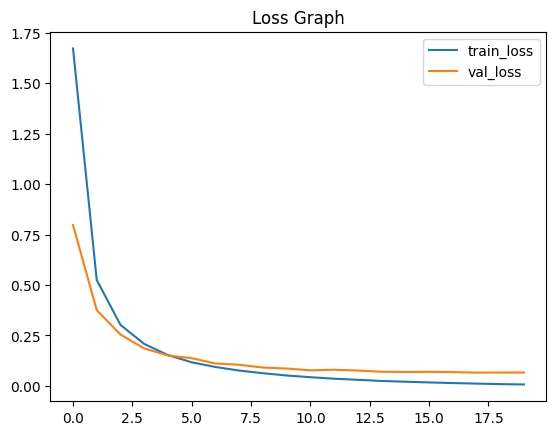

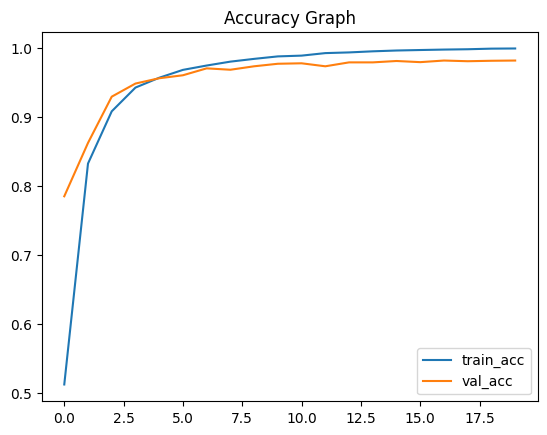

In [27]:
import matplotlib.pyplot as plt

# Loss graph
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Graph")
plt.show()
